In [20]:
from app.data.Document import RAW_DOCUMENT
from app.models.Chunks import ParentChunk
from app.utils.Parser import parse_document
from app.utils.Embedder import embed_and_store
from app.utils.Retriever import search_children
from app.utils.parentembedder import summarize_and_store


# def print_structure(parents: list[ParentChunk]) -> None:
#     """ساختار parent-child را به‌صورت درخت نمایش می‌دهد."""
#     print("=" * 60)
#     print("ساختار Parent-Child سند RAG فارسی")
#     print("=" * 60)

#     for parent in parents:
#         preview = parent.content[:80].replace("\n", " ") + "..."
#         print(f"\n📁 Parent [{parent.id}]: {parent.title}")
#         print(f"   محتوا (پیش‌نمایش): {preview}")

#         if parent.children:
#             for child in parent.children:
#                 child_preview = child.content[:60].replace("\n", " ") + "..."
#                 print(f"   └─ Child [{child.id}]: {child.title}")
#                 print(f"             محتوا: {child_preview}")
#         else:
#             print("   └─ (بدون زیرعنوان)")

#     total_children = sum(len(p.children) for p in parents)
#     print("\n" + "=" * 60)
#     print(f"✅ تعداد کل Parents  : {len(parents)}")
#     print(f"✅ تعداد کل Children : {total_children}")
#     print("=" * 60)




def main() -> None:
    parents = parse_document(RAW_DOCUMENT)


    # # ذخیره
    # count = embed_and_store(parents, collection_name="rag_chunks")
    # print(f"{count} child chunk ذخیره شد")


    # count = summarize_and_store(parents, collection_name="rag_parent_chunks")
    # print(f"{count} parent chunk خلاصه و ذخیره شد")



# results = search(
#     question="دقت بازیابی از معیار های ارزیابی rag را توضیح بده",
#     top_k=5,
# )
# for r in results:
#     print(f"[{r.score:.3f}] {r.child_title}")
#     print(r.child_content)
#     print("---")





# جستجو در child ها (دقیق‌تر، granular)
# child_results = search_children("دقت بازیابی چه چیزی را نشان میدهد و در اجزای rag دومورد اول را تعریف کن", top_k=10)
# for r in child_results:
#     print(f"{r.child_title}")
#     print(r.child_content)
#     print("parent title : ",r.parent_title)
#     print("parent id : ",r.parent_id)
#     print("child id : ",r.child_id)
#     print("----------------------------------------------------------")


# # جستجو در parent ها (context کامل‌تر)
# parent_results = search_parents("یک خلاصه ای از اینکه rag چیه بهم بگو", top_k=5)
# for r in parent_results:
#     print(f"[{r.score:.3f}] {r.parent_title}")
#     print(r.parent_content)
#     print("---")




# parent_content را به LLM می‌دهی (نه summary را)
# context = parent_results[0].parent_content



    print(parents)
    # first = parents[0]

    # print(first.id)
    # print(first.title)
    # print(first.content)
    # print(first.children)



    # print_structure(parents)


if __name__ == "__main__":
    main()

[ParentChunk(id='1', title='مقدمه و پیشینه', content='[1.1] معرفی مدل\u200cهای زبانی بزرگ (LLM)\nدر دنیای امروز، مدل\u200cهای زبانی بزرگ (LLM) به یکی از پایه\u200cهای اصلی نرم\u200cافزارهای هوشمند تبدیل شده\u200cاند.\nاین مدل\u200cها قادرند متون طبیعی را درک کرده، آن\u200cها را تحلیل کنند و پاسخ\u200cهایی دقیق و روان تولید نمایند.\nبا این حال، یکی از بزرگ\u200cترین چالش\u200cهای این مدل\u200cها آن است که دانش آن\u200cها به زمان آموزش محدود می\u200cشود\nو دسترسی مستقیمی به داده\u200cهای جدید، اختصاصی یا سازمانی ندارند.\n\n[1.2] معرفی رویکرد RAG\nبرای رفع این محدودیت، رویکرد «بازیابی-افزوده تولید» یا Retrieval-Augmented Generation (RAG)\nمطرح شد. این رویکرد ترکیبی از دو مرحله اصلی است:\n۱. در مرحله اول، اطلاعات مرتبط از یک پایگاه دانش بیرونی بازیابی می\u200cشود.\n۲. در مرحله دوم، مدل زبانی از این اطلاعات بازیابی\u200cشده به\u200cعنوان زمینه (Context) استفاده می\u200cکند\nتا پاسخ نهایی را تولید نماید.\n\n[1.3] تاریخچه و کاربردهای RAG\nمعماری RAG نخستین بار توسط لوئیس و همکارانش در سال ۲۰۲

In [10]:
from app.services.retriever import search_children
FIRST_SEARCH_TOP_K = 5
query = "آینده rag چیه"
child_results = search_children(
        query,
        collection_name="loader_children",
        top_k=FIRST_SEARCH_TOP_K,
    )

In [11]:
child_results

[ChildSearchResult(parent_title='آینده    RAG', child_title='آینده    RAG', child_content='آینده RAG به سمت سیستم های پیشرفته تر و هوشمندتر در حال حرکت است، از جمله:\n•   Streaming RAG: تولید پاسخ به صورت تدریجی\n•   Multimodal RAG:   پردازش همزمان متن، تصویر، جدول و نمودار\n•   RAG با حافظه بلندمدت: نگهداری تاریخچه مکالمات و استفاده از آن در پاسخ ها\nبا افزایش ظرفیت مدل های زبانی و گسترش پنجره زمینه (Context Window)  ، برخی کاربردهای\nسنتی RAG ممکن است تغییر کنند، اما در سیستم هایی با داده های بزرگ و نیاز به به ،روزرسانی مداوم\nهمچنان نقش کلیدی خواهد داشت.', parent_id='9'),
 ChildSearchResult(parent_title='اجزای اصلی یک سیستم   RAG', child_title='مقدمه ای برای: اجزای اصلی یک سیستم   RAG', child_content='یک سیستم RAG   از چندین مؤلفه کلیدی تشکیل شده است که هر یک نقش مهمی در کیفیت نهایی\nپاسخ ها ایفا می کنند.', parent_id='2'),
 ChildSearchResult(parent_title='معیارهای ارزیابی   RAG', child_title='مقدمه ای برای: معیارهای ارزیابی   RAG', child_content='ارزیابی کیفیت یک سیستم RAG از چندین 

In [12]:
from app.rag.decider import decide_context , print_decision_result


result = decide_context(query, child_results)
print_decision_result(result)

Parent IDs : ['9']
Context نهایی:
------------------------------------------------------------
### [9] آینده    RAG

آینده RAG به سمت سیستم های پیشرفته تر و هوشمندتر در حال حرکت است، از جمله:
•   Streaming RAG: تولید پاسخ به صورت تدریجی
•   Multimodal RAG:   پردازش همزمان متن، تصویر، جدول و نمودار
•   RAG با حافظه بلندمدت: نگهداری تاریخچه مکالمات و استفاده از آن در پاسخ ها
با افزایش ظرفیت مدل های زبانی و گسترش پنجره زمینه (Context Window)  ، برخی کاربردهای
سنتی RAG ممکن است تغییر کنند، اما در سیستم هایی با داده های بزرگ و نیاز به به ،روزرسانی مداوم
همچنان نقش کلیدی خواهد داشت.


/home/son/Desktop/rag/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


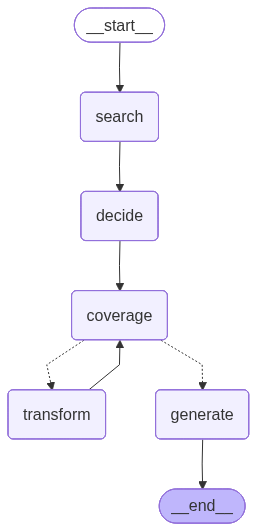

In [1]:
from app.utils.graph import _rag_app

from IPython.display import display, Image

display(Image(_rag_app.get_graph().draw_mermaid_png()))